In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [2]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train'] ['text']
train_label = emotion_dataset['train'] ['label']
test_text = emotion_dataset['test'] ['text']
test_label = emotion_dataset['test'] ['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [3]:
label_names = emotion_dataset['train'].features['label'].names
df_train = pd.DataFrame(columns=['text', 'label'])
df_train['text'] = train_text
df_train['label'] = [label_names[i] for i in train_label]
df_test = pd.DataFrame(columns=['text', 'label'])
df_test['text'] = test_text
df_test['label'] = [label_names[i] for i in test_label]

In [4]:
df_test.isnull().sum()

,0
text,0
label,0


<Axes: xlabel='label', ylabel='count'>

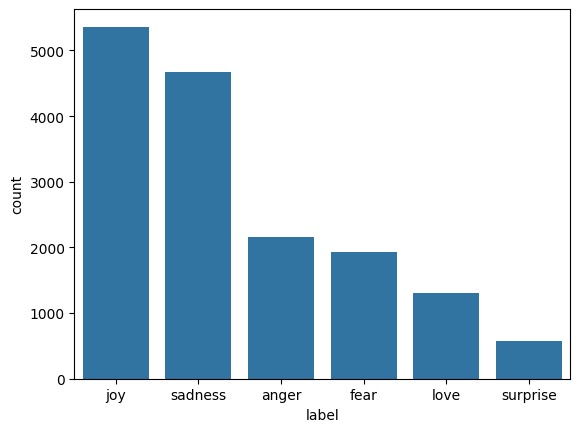

In [5]:
sns.countplot(x='label', data=df_train, order = df_train['label'].value_counts().index)

**
Data Preprocessing - Using NLP**

In [6]:
from tensorflow import train
max_words = 10000
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
Tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
Tokenizer.fit_on_texts(df_train['text'])
train_sequences = Tokenizer.texts_to_sequences(df_train['text'])
test_sequences = Tokenizer.texts_to_sequences(df_test['text'])
train_padded = pad_sequences(train_sequences, maxlen=60, padding='post', truncating='post')
test_padded = pad_sequences(test_sequences, maxlen=60, padding='post', truncating='post')
train_labels = np.array(train_label)
test_labels = np.array(test_label)
num_classes = len(np.unique(train_labels))



**Shared training utilities**

In [7]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)

In [8]:
class_weight_dict = dict(enumerate(class_weights))

In [9]:
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True )


Plain Foundation Model

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

In [11]:
# rnn_model = Sequential([
#     Embedding(input_length=60, input_dim=max_words, output_dim=128),
#     SimpleRNN(units = 128, return_sequences=True),

#     Dropout(0.5),
#     SimpleRNN(units = 64),

#     Dropout(0.5),
#     Dense(num_classes, activation='softmax')
# ])
# rnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [12]:
# rnn_model.fit(
#     train_padded,
#     train_labels,
#     validation_data=(test_padded, test_labels),
#     epochs=20,
#     batch_size=32,

#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

Stnadard LSTM

In [13]:
# lstm_model = Sequential([
#     Embedding(input_length=60, input_dim=max_words, output_dim=128),
#     LSTM(units = 128, return_sequences=True),

#     Dropout(0.5),
#     LSTM(units = 64),

#     Dropout(0.5),
#     Dense(num_classes, activation='softmax')
# ])
# lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# lstm_model.fit(
#     train_padded,
#     train_labels,
#     validation_data=(test_padded, test_labels),
#     epochs=20,
#     batch_size=32,

#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )


GRU

In [14]:
# gru_model = Sequential([
#     Embedding(input_length=60, input_dim=max_words, output_dim=128),
#     GRU(units = 128, return_sequences=True),

#     Dropout(0.5),
#     GRU(units = 64),

#     Dropout(0.5),
#     Dense(num_classes, activation='softmax')
# ])
# gru_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
# gru_model.fit(
#     train_padded,
#     train_labels,
#     validation_data=(test_padded, test_labels),
#     epochs=20,
#     batch_size=32,
#     validation_split=0.2,
#     class_weight=class_weight_dict,
#     callbacks=[early_stopping]
# )

In [15]:
# result_df = pd.DataFrame({
#     'model': ['RNN', 'LSTM', 'GRU'],
#     'accuracy': [rnn_model.evaluate(test_padded, test_labels)[1], lstm_model.evaluate(test_padded, test_labels)[1], gru_model.evaluate(test_padded, test_labels)[1]]

#     'Test Loss': [rnn_model.evaluate(test_padded, test_labels)[0], lstm_model.evaluate(test_padded, test_labels)[0], gru_model.evaluate(test_padded, test_labels)[0]]

# })

SyntaxError: invalid syntax. Perhaps you forgot a comma? (2147387274.py, line 3)

In [19]:
from tensorflow.keras.layers import Bidirectional

In [20]:
BIGRU = Sequential([
    Embedding(input_length=50, input_dim=max_words, output_dim=300),
    Bidirectional(GRU(units = 128, return_sequences=True)),

    Dropout(0.5),
    Bidirectional(GRU(units = 64)),

    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])
BIGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [21]:
BIGRU.fit(
    train_padded,
    train_labels,
    validation_data=(test_padded, test_labels),
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 20s 22ms/step - accuracy: 0.5825 - loss: 1.0135 - val_accuracy: 0.8800 - val_loss: 0.3932
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 13s 26ms/step - accuracy: 0.9179 - loss: 0.2325 - val_accuracy: 0.9125 - val_loss: 0.2581
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9469 - loss: 0.1475 - val_accuracy: 0.9175 - val_loss: 0.2501
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.9591 - loss: 0.1090 - val_accuracy: 0.9255 - val_loss: 0.2463
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - accuracy: 0.9644 - loss: 0.0999 - val_accuracy: 0.9170 - val_loss: 0.2758
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9761 - loss: 0.0687 - val_accuracy: 0.9275 - val_loss: 0.2612
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9781 - loss: 0.0639 - val_accuracy: 0.9210 - val_loss: 0.2744


In [22]:
BIGRU_Loss, BIGRU_accuracy = BIGRU.evaluate(test_padded, test_labels)
print(f'BIGRU Loss: {BIGRU_Loss}')
print(f'BIGRU Accuracy: {BIGRU_accuracy}')

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9255 - loss: 0.2463
BIGRU Loss: 0.24629181623458862
BIGRU Accuracy: 0.9254999756813049


In [23]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
BIGRU_prediction = BIGRU.predict(test_padded)
BIGRU_prediction = np.argmax(BIGRU_prediction, axis=1)
BIGRU_prediction


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


array([0, 0, 0, ..., 1, 1, 5])

<Axes: >

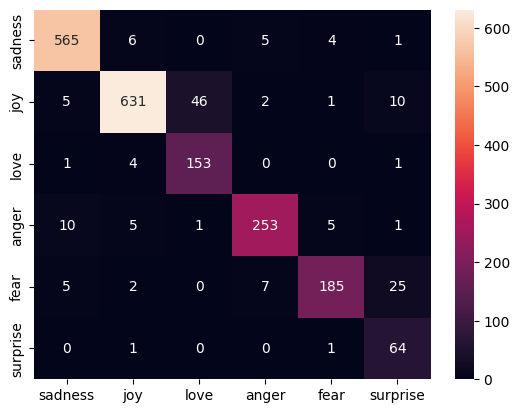

In [25]:
sns.heatmap(confusion_matrix(test_labels, BIGRU_prediction), annot=True, fmt='d',xticklabels=label_names, yticklabels=label_names)

Fianl Predictions

In [28]:
Sample_texts = [
    "I can't believe how happy i am right now",
    'I feel so alone and hopeless today',
    'I am furious that they cancelled the trip at the last minute.'
]
sample_sequencces = Tokenizer.texts_to_sequences(Sample_texts)
sample_padded = pad_sequences(sample_sequencces, maxlen=60, padding='post', truncating='post')
sample_prediction = np.argmax(BIGRU.predict(sample_padded), axis=1)
for i in range(len(Sample_texts)):
  print(f"Text: {Sample_texts[i]}")
  print(f"Predicted Label: {label_names[sample_prediction[i]]}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Text: I can't believe how happy i am right now
Predicted Label: joy
Text: I feel so alone and hopeless today
Predicted Label: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Label: anger


In [36]:
import os
import pickle
model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True)
model_path = os.path.join(model_dir, 'BIGRU.keras')
with open(model_path, 'wb') as f:
  pickle.dump(BIGRU, f)
#Model saved

with open(os.path.join(model_dir, 'Tokenizer.pkl'), 'wb') as f:
  pickle.dump(Tokenizer, f)
#Tokenizer saved